In [5]:
from pathlib import Path
from src.data import train_chain, val_chain, return_split, ChestXrayDataset
from PIL import Image
from torchvision import transforms
import torch
import matplotlib.pyplot as plt
import pandas as pd
from src.config import MEAN, STD
from torch.utils.data import DataLoader

In [2]:
train_df, val_df, test_df = return_split()
transform = train_chain()

Cal of mean and std 

In [3]:
def test():
    SIZE = 224
    return transforms.Compose([transforms.Grayscale(num_output_channels=1), transforms.Resize(SIZE), transforms.CenterCrop(SIZE), 
                        transforms.ToTensor()])
trans_test = test()

In [4]:
tensors = []
for _, row in train_df.iterrows():
    img = Image.open(row["filepath"])
    tensors.append(trans_test(img))

stack = torch.stack(tensors)   # shape: [N, 1, 224, 224]
mean = stack.mean()
std = stack.std()
print(mean.item(), std.item())

0.5699814558029175 0.1791200488805771


img transformation checking

In [5]:
row = train_df.iloc[1]
img = Image.open(row["filepath"])
img_resized = transform(img)
#img_resized
print(img_resized.shape)

torch.Size([1, 224, 224])


debugging img visible

In [6]:
debug_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize(224),
    transforms.CenterCrop(224),
])

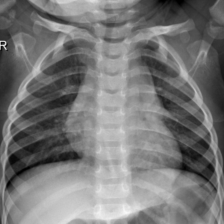

In [7]:
img_resized = debug_transform(img)
img_resized 

checking on a batch of 300

In [9]:
sample_df = train_df.sample(n=300, random_state=42).reset_index(drop=True)

In [10]:
tensors = []
for _, row in sample_df.iterrows():
    img = Image.open(row["filepath"])
    tensors.append(transform(img))

stack = torch.stack(tensors)   # shape: [N, 1, 224, 224]
mean = stack.mean()
std = stack.std()
print(mean.item(), std.item())

0.012272416613996029 1.0210970640182495


grid of 6 transformed images, 3 NORMAL + 3 PNEUMONIA

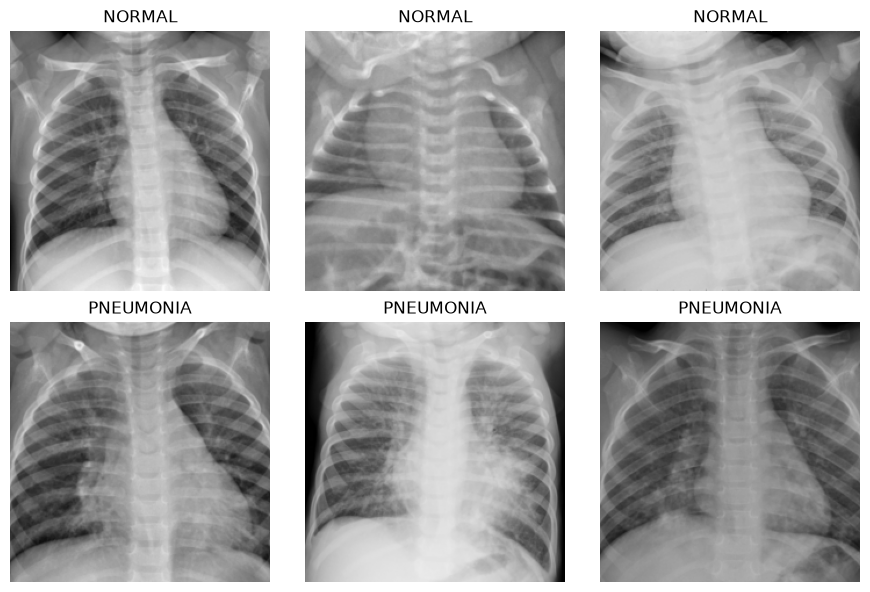

In [ ]:
normal_rows = train_df[train_df["label"] == "NORMAL"].sample(n=3, random_state=42)
pneumonia_rows = train_df[train_df["label"] == "PNEUMONIA"].sample(n=3, random_state=42)
sample_rows = pd.concat([normal_rows, pneumonia_rows])

fig, axes = plt.subplots(2, 3, figsize=(9, 6))

for ax, (_, row) in zip(axes.flat, sample_rows.iterrows()):
    img = Image.open(row["filepath"])
    img_t = transform(img)                    # (1, 224, 224), normalized

    img_t = img_t * STD + MEAN                # denormalized: back to [0, 1]
    img_np = img_t.squeeze(0).numpy()          # (1, 224, 224) -> (224, 224)

    ax.imshow(img_np, cmap="gray", vmin=0, vmax=1)
    ax.set_title(row["label"])
    ax.axis("off")

plt.tight_layout()
plt.show()

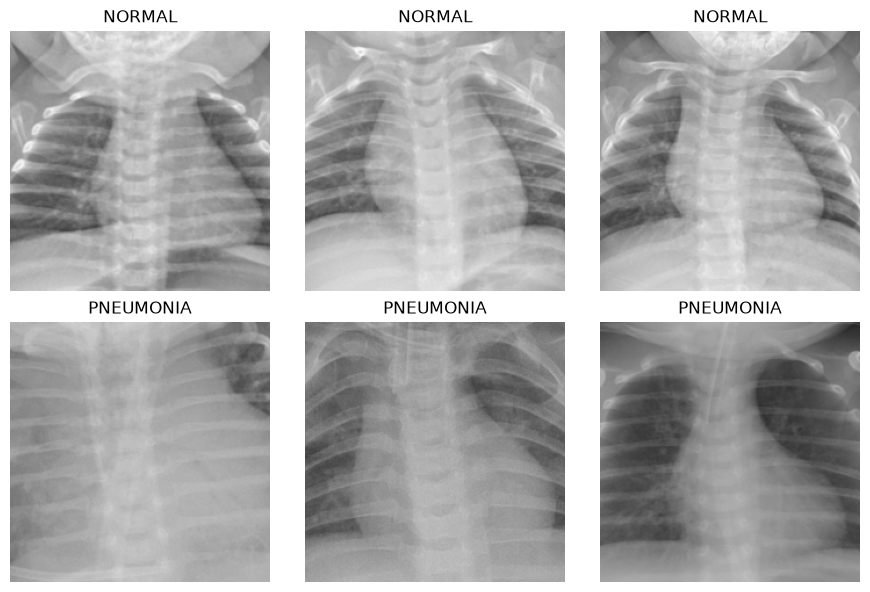

In [33]:
normal_rows = train_df[train_df["label"] == "NORMAL"].sort_values("aspect_ratio", ascending= False).head(3)
pneumonia_rows = train_df[train_df["label"] == "PNEUMONIA"].sort_values("aspect_ratio", ascending= False).head(3)
sample_rows = pd.concat([normal_rows, pneumonia_rows])

fig, axes = plt.subplots(2, 3, figsize=(9, 6))

for ax, (_, row) in zip(axes.flat, sample_rows.iterrows()):
    img = Image.open(row["filepath"])
    img_t = transform(img)                    # (1, 224, 224), normalized

    img_t = img_t * STD + MEAN                # denormalized: back to [0, 1]
    img_np = img_t.squeeze(0).numpy()          # (1, 224, 224) -> (224, 224)

    ax.imshow(img_np, cmap="gray", vmin=0, vmax=1)
    ax.set_title(row["label"])
    ax.axis("off")

plt.tight_layout()
plt.show()

## DataLoader and testing the batch

In [10]:
train_Dataset = ChestXrayDataset(train_df, train_chain)
val_Dataset = ChestXrayDataset(val_df, val_chain)
test_Dataset = ChestXrayDataset(test_df, val_chain)
print("len train: " + str(len(train_Dataset)) + " len val: " + str(len(val_Dataset)) + " len test: " + str(len(test_Dataset)))

len train: 3925 len val: 982 len test: 618


In [11]:
train_loader = DataLoader(train_Dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_Dataset, batch_size=32, shuffle=False, num_workers=0)
test_loader = DataLoader(test_Dataset, batch_size=32, shuffle=False, num_workers=0)

In [23]:
images, labels = next(iter(train_loader))
print(images.shape, images.dtype, labels.shape, labels.dtype)
print(labels)

torch.Size([32, 1, 224, 224]) torch.float32 torch.Size([32]) torch.int64
tensor([1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1,
        1, 0, 0, 1, 0, 1, 1, 1])


In [ ]:
print(images.min(), images.max(), images.mean())

tensor(-3.1826) tensor(2.4009) tensor(0.0075)


full pass over train_loader: timing + label count check

In [36]:
import time

all_labels = []

start = time.perf_counter()
for imgs, labels in train_loader:
    all_labels.append(labels)
elapsed = time.perf_counter() - start

all_labels = torch.cat(all_labels)
counts = torch.bincount(all_labels)

print(f"zeros (NORMAL): {counts[0].item()}")
print(f"ones (PNEUMONIA): {counts[1].item()}")
print(f"epoch time (only data loading): {elapsed:.2f} s")

zeros (NORMAL): 1072
ones (PNEUMONIA): 2853
epoch time (only data loading): 17.17 s


## First simple model

In [2]:
from src.model import Model

In [3]:
model = Model()
print(model)

Model(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (maxPool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (maxPool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (maxPool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (maxPool4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (globalmean): AdaptiveAvgPool2d(output_size=1)
  (linear1): Linear(in_features=128, out_features=2, bias=True)
)


In [6]:
test = torch.randn(4, 1, 224, 224)


In [7]:
result = model(test)
print(result)

tensor([[0.0369, 0.0152],
        [0.0366, 0.0161],
        [0.0367, 0.0170],
        [0.0375, 0.0162]], grad_fn=<AddmmBackward0>)


In [8]:
sum(p.numel() for p in model.parameters())

97410